# Data Exploration - Twitter Sentiment Analysis

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
import kagglehub
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
# Download the latest version of the dataset
path = kagglehub.dataset_download("kazanova/sentiment140")
print("Path to dataset files:", path)

100%|██████████| 80.9M/80.9M [00:06<00:00, 13.9MB/s]

Extracting files...


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\kazanova\sentiment140\versions\2


In [16]:
# Load dataset (using sample for demo)
df = pd.read_csv("../data/twitter_sentiment_sample.csv", encoding='latin-1', header=None, names=['target', 'ids', 'date', 'flag', 'user', 'text'])
df.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   target  1600000 non-null  int64
 1   ids     1600000 non-null  int64
 2   date    1600000 non-null  str  
 3   flag    1600000 non-null  str  
 4   user    1600000 non-null  str  
 5   text    1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 73.2 MB


In [18]:
# Check for missing values
df.isnull().sum()

target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64

In [20]:
df['target'].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

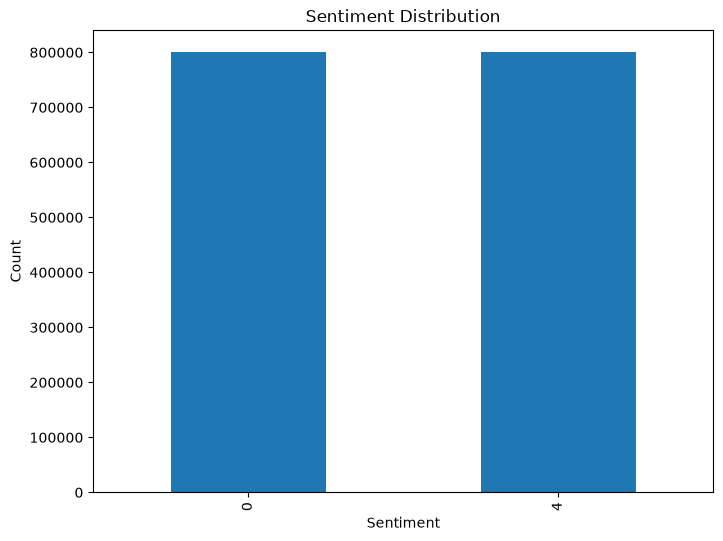

In [21]:
# Sentiment distribution
plt.figure(figsize=(8, 6))
df['target'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

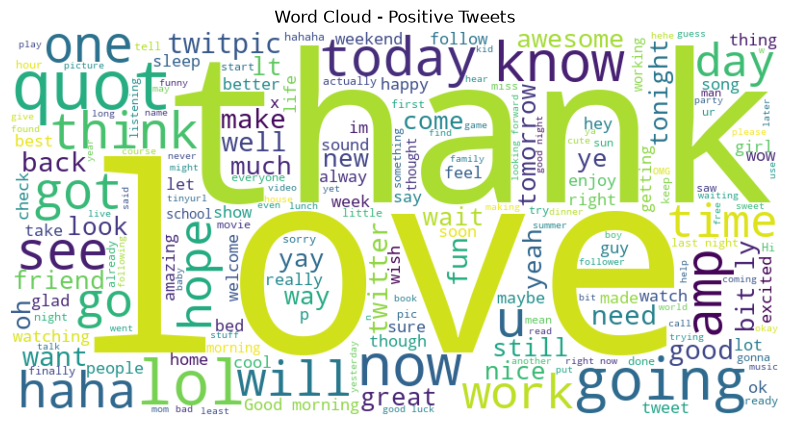

In [24]:
# Word Cloud for positive tweets
positive_tweets = ' '.join(df[df['target'] == 'positive']['text'])
# Map the numeric target column to sentiment labels used later in the notebook
if 'sentiment' not in df.columns:
    df['sentiment'] = df['target'].map({0: 'negative', 2: 'neutral', 4: 'positive'})

positive_tweets = ' '.join(df[df['sentiment'] == 'positive']['text'].fillna('').astype(str))

if positive_tweets.strip():
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_tweets)
else:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate("positive")
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Tweets')
plt.show()

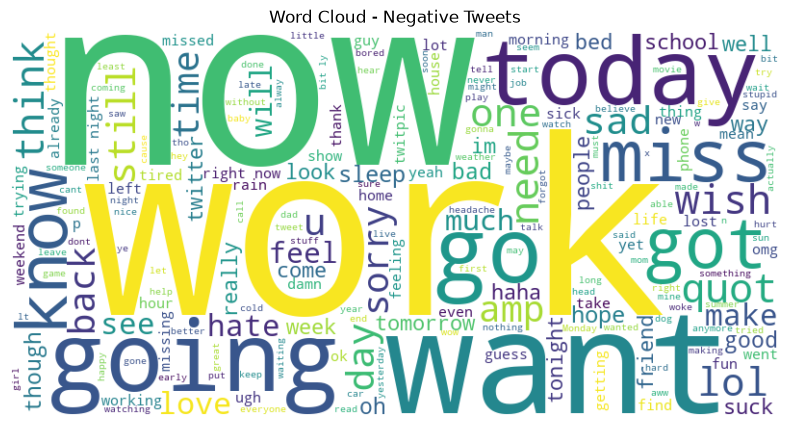

In [25]:
# Word Cloud for negative tweets
negative_tweets = ' '.join(df[df['sentiment'] == 'negative']['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_tweets)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Tweets')
plt.show()

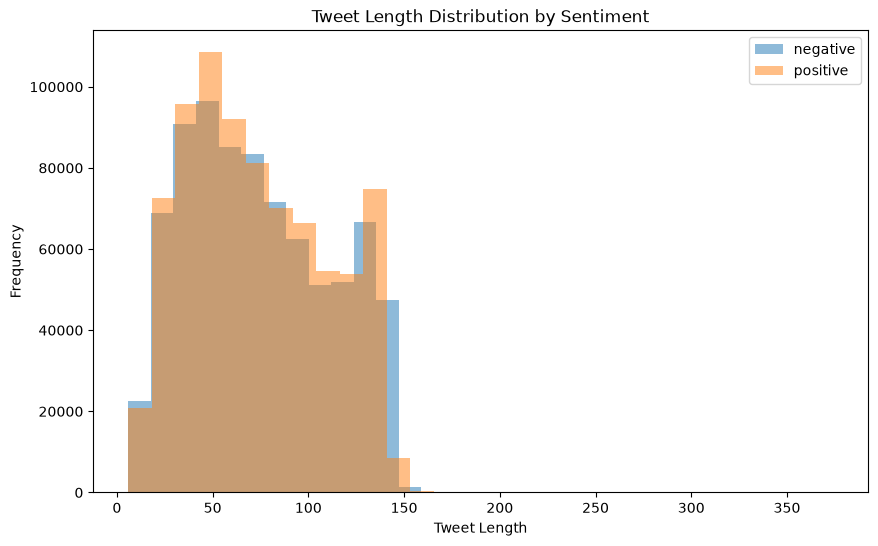

In [26]:
# Tweet length distribution
df['tweet_length'] = df['text'].str.len()
plt.figure(figsize=(10, 6))
for sentiment in df['sentiment'].unique():
    subset = df[df['sentiment'] == sentiment]
    plt.hist(subset['tweet_length'], alpha=0.5, label=sentiment, bins=30)
plt.legend()
plt.title('Tweet Length Distribution by Sentiment')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.show()